# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Report Discussion:**  In problem 2, why is the expected result as so? Did you get the expected result in both eigenenergies and ground state wavefunction? why or why not
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Maribao, Jake Agustin
- _Student No._: 2023-08777
- _Section_: TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Eigenfunctions](Eigenfunctions_of_Harmonic_Oscillator.png)

**Figure 1 (Problem 1).** The five lowest eigenfunctions of the harmonic oscillator
($m = \hbar = 1$, $\omega = 1$) obtained from `np.linalg.eigh` on the matrix Hamiltonian,
each normalised to $\int|\psi_n|^2dx = 1$ and offset vertically by its eigenvalue
$\mathscr{E}_n$ (dotted lines), with $V = \tfrac12 m\omega^2x^2$ overlaid. The eigenvalues
fall at $\hbar\omega(n+\tfrac12) = 0.5, 1.5, \dots, 4.5$, each $\psi_n$ has $n$ nodes, and
the wavefunctions decay to zero outside the classical turning points where $V > \mathscr{E}_n$.

![Eigenenergy](Eigenenergies_of_the_Hamiltonian.png)

**Figure 2 (Problem 2a).** The 100 lowest eigenenergies of the oscillator in a uniform
field ($qE = 1$), computed on $x \in [-20, 20]$ with $\Delta x = 0.02$ (markers), against
the theoretical $\hbar\omega(n+\tfrac12) - q^2E^2/2m\omega^2$ (line). With $\omega = 1$
the field offset is exactly $-\tfrac12$, so the theoretical energies are the integers
$\mathscr{E}_n = n$. Numerical and theoretical values agree to within $0.06$ up to
$n = 50$ and to within $0.25$ (0.25%) at $n = 99$; the small drift is discussed below.

![Probability Density](Potential_&_Probability_Density.png)

**Figure 3 (Problem 2b).** The potential $V = \tfrac12 m\omega^2x^2 + qEx$ (left axis)
and the ground-state probability density $|\psi_0|^2$ (right axis). The density is a
Gaussian centred on the potential minimum $x_0 = -qE/m\omega^2 = -1$ (dashed) with width
$\sqrt{\hbar/2m\omega} = 0.707$, and the ground-state energy $\mathscr{E}_0 = 0$ (dotted)
sits half a quantum $\hbar\omega/2$ above the bottom of the well at $V(x_0) = -\tfrac12$.

### Report discussion

**In Problem 2, why is the expected result as so?**

Completing the square in $V = \tfrac12 m\omega^2x^2 + qEx$ gives
$V = \tfrac12 m\omega^2(x - x_0)^2 - q^2E^2/(2m\omega^2)$ with $x_0 = -qE/(m\omega^2)$. A
linear term therefore does not change the shape of the oscillator: it moves the minimum
to $x_0$ and lowers the whole potential by a constant. The Schrödinger equation is
translation invariant, and a constant added to $\hat H$ adds the same constant to every
eigenvalue, so the eigenfunctions are the field-free ones shifted to $x_0$ and the
energies are $\hbar\omega(n+\tfrac12)$ minus $q^2E^2/(2m\omega^2)$, with the spacing
$\hbar\omega$ unchanged. For $m = \hbar = 1$, $\omega = 1$, $qE = 1$ this predicts
$x_0 = -1$, an offset of exactly $-\tfrac12$ that cancels the zero-point $+\tfrac12$, so
$\mathscr{E}_n = n$ with the ground state at $0$, and a ground-state density that is a
Gaussian centred on $x_0$ with width $\sqrt{\hbar/2m\omega} = 0.707$.

**Did you get the expected result in both eigenenergies and ground state wavefunction? Why or why not?**

Yes. The ground state gives $\mathscr{E}_0 = -0.00001$ against $0$,
$\langle x\rangle = -1.0000$ and width $0.7071$, matching the shifted-oscillator
prediction to four digits. The energies stay within $0.06$ of $\mathscr{E}_n = n$ up to $n = 50$, then
drift slightly below, reaching $-0.25$ (0.25%) at $n = 99$. The drift is the three-point
stencil, which represents the kinetic energy as $(\hbar^2/m\Delta x^2)(1 - \cos k\Delta x)$
instead of $\hbar^2k^2/2m$, an underestimate of order $(k\Delta x)^2/12$ that grows with
$n$ because $k$ does. It is a discretisation artefact, reduced by a finer $\Delta x$.

### Other comments
- Problem 1(a) was done by hand. The 5-point structure check in the code reproduces the
  hand-derived matrix.
- All quantities are in natural units ($m = \hbar = 1$). "Electron" only fixes the sign of
  $q$, which cancels in $qE = 1$.


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=\mathscr{E}_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + \mathscr{E}_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

**Problem 1 notes**

*(a)* Accomplished by handwritten computation. Applying the three-point second-difference
formula to every $\psi_i$ gives the tridiagonal matrix shown above ($1, -2, 1$ along the
diagonals, divided by $(\Delta x)^2$), and $\hat T$ is that matrix times $-\hbar^2/2m$.

*(b)* `hamiltonian(x_pos, potential_array, mass)` builds $\hat T$ from three `np.eye`
calls (offsets $-1, 0, +1$), reads $\Delta x$ from `x_pos`, and adds $\hat V$ as
`np.diag(potential_array)`. The result is real and symmetric, so `np.linalg.eigh` (the
symmetric eigensolver, eigenvalues in ascending order) is the right tool in (c).

*(c)* With $V = \tfrac12 m\omega^2x^2$ the eigenvalues should be $\hbar\omega(n+\tfrac12)$.
`eigh` returns unit eigenvectors; dividing by $\sqrt{\Delta x}$ makes
$\int|\psi|^2dx = 1$. An eigenvector's overall sign is arbitrary, so each is flipped to
make its rightmost lobe positive (the Hermite convention) before plotting
$\psi_n + \mathscr{E}_n$ over $V$. Grid: $x \in [-8, 8]$, $\Delta x = 0.02$, wide enough
that the fifth state (turning points at $\pm 3.0$) has decayed to zero at the walls.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

hbar = 1.0   # natural units throughout: hbar = m = 1


def hamiltonian(x_pos, potential_array, mass):
    """Matrix Hamiltonian T + V on a uniform grid.

    x_pos, potential_array : 1-D arrays of length N, the grid points x_i and
        the potential values V(x_i).
    mass : scalar.
    Returns an N x N symmetric float array. T uses the three-point second
    difference, so it is tridiagonal with -2 on the diagonal and 1 on the
    first off-diagonals, scaled by -hbar^2 / (2 m dx^2). V is diagonal.
    """
    N = len(x_pos)
    dx = x_pos[1] - x_pos[0]
    T = -hbar**2/(2*mass*dx**2) * (np.eye(N, k=-1) - 2*np.eye(N) + np.eye(N, k=1))
    return T + np.diag(potential_array)


# Structure check: 5-point grid, V = 0, divided by the prefactor -> the boxed matrix.
x_test = np.linspace(0, 1, 5)
prefactor = -hbar**2/(2*1.0*(x_test[1] - x_test[0])**2)
print((hamiltonian(x_test, np.zeros(5), 1.0) / prefactor).round().astype(int))

[[-2  1  0  0  0]
 [ 1 -2  1  0  0]
 [ 0  1 -2  1  0]
 [ 0  0  1 -2  1]
 [ 0  0  0  1 -2]]


 n   numerical   hbar*omega*(n + 1/2)
 0     0.49999     0.50000
 1     1.49994     1.50000
 2     2.49984     2.50000
 3     3.49969     3.50000
 4     4.49949     4.50000


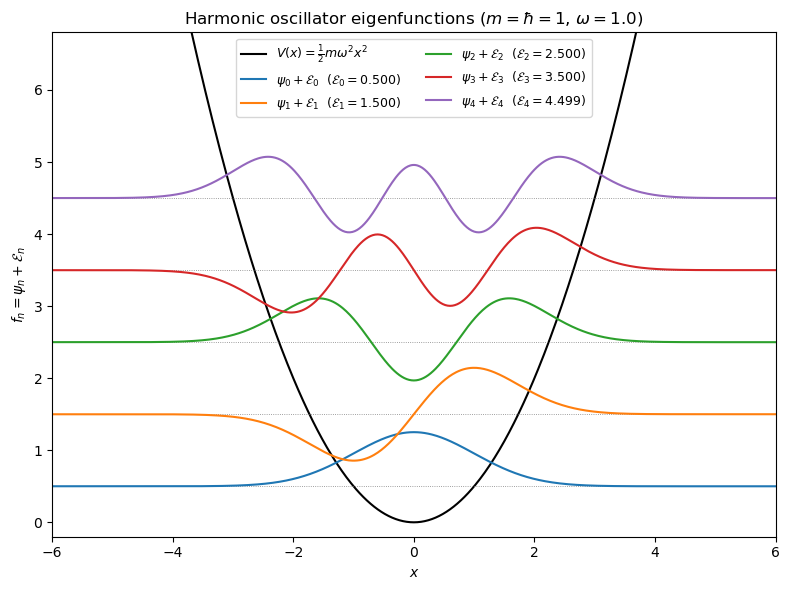

In [2]:
m, omega = 1.0, 1.0
x = np.linspace(-8, 8, 801)
dx = x[1] - x[0]
V_ho = 0.5*m*omega**2*x**2

energies, states = np.linalg.eigh(hamiltonian(x, V_ho, m)) #the call to hamiltonian() is nested inside np.linalg.eigh()
n_show = 5
psi = states[:, :n_show] / np.sqrt(dx)          # normalise: sum |psi|^2 dx = 1
for k in range(n_show):                          # sign convention: rightmost lobe positive
    tail = np.nonzero(np.abs(psi[:, k]) > 1e-3*np.abs(psi[:, k]).max())[0][-1]
    psi[:, k] *= np.sign(psi[tail, k])

print(" n   numerical   hbar*omega*(n + 1/2)")
for k in range(n_show):
    print(f"{k:>2}   {energies[k]:9.5f}   {hbar*omega*(k + 0.5):9.5f}")


fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, V_ho, 'k-', lw=1.5, label=r'$V(x) = \frac{1}{2}m\omega^2x^2$')
for k in range(n_show):
    ax.axhline(energies[k], color='gray', lw=0.6, ls=':')
    ax.plot(x, psi[:, k] + energies[k], lw=1.5,
            label=rf'$\psi_{k} + \mathcal{{E}}_{k}$  ($\mathcal{{E}}_{k} = {energies[k]:.3f}$)')
ax.set_xlim(-6, 6)
ax.set_ylim(-0.2, 6.8)
ax.set_xlabel('$x$')
ax.set_ylabel(r'$f_n = \psi_n + \mathcal{E}_n$')
ax.set_title(rf'Harmonic oscillator eigenfunctions ($m = \hbar = 1$, $\omega = {omega}$)')
ax.legend(loc='upper center', ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig('Eigenfunctions_of_Harmonic_Oscillator')

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

**Problem 1 code summary**

The script discretises the Schrödinger equation on a grid so that $\hat H$ becomes an
$N \times N$ matrix and the eigenvalue problem can be handed to `np.linalg.eigh`. One
function builds $\hat H$ for any grid, potential and mass, using `np.eye` offsets for the
tridiagonal kinetic term so no loops are needed; a 5-point structure check confirms it
matches the matrix derived by hand. The harmonic-oscillator test compares the five lowest
eigenvalues with $\hbar\omega(n+\tfrac12)$ before the eigenfunctions are plotted.

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
\mathscr{E}_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

**Problem 2 notes**

*Units.* Same natural units as Problem 1 ($m = \hbar = 1$, $\omega = 1.0$). "Electron"
fixes the sign of $q$, and $E = q^{-1}$ makes $qE = 1$ whatever that sign, so
$V = \tfrac12 m\omega^2x^2 + x$.

*(a)* Completing the square, $V = \tfrac12 m\omega^2(x - x_0)^2 - q^2E^2/(2m\omega^2)$
with $x_0 = -qE/(m\omega^2) = -1$: the same oscillator, shifted and lowered by a
constant, which is where the theoretical $\mathscr{E}_n$ comes from. The grid must hold
the 100th state, whose turning points are at $x_0 \pm \sqrt{2\mathscr{E}}/\omega \approx
x_0 \pm 14.1$, so $x \in [-20, 20]$ is used with $\Delta x = 0.02$ to resolve the shortest
wavelength ($2\pi/k \approx 0.45$).

*(b)* The ground-state density is $|\psi_0|^2$ with $\int|\psi_0|^2dx = 1$; its mean and
width are compared with $x_0$ and $\sqrt{\hbar/2m\omega}$.

E_0 numerical = -0.00001, theory = 0.00000
max |E_n - theory| for n < 50 : 6.134e-02
E_99 - theory                  : -2.481e-01  (relative -2.51e-03)


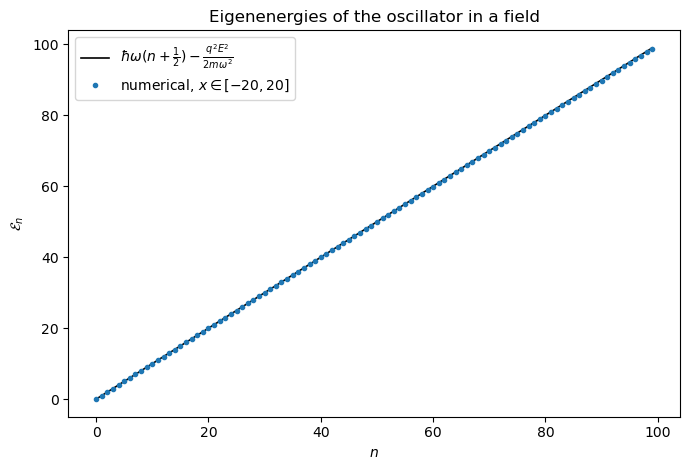

In [3]:
qE = 1.0                                   # E = 1/q  =>  qE = 1, sign of q irrelevant
n = np.arange(100)
E_theory = hbar*omega*(n + 0.5) - qE**2/(2*m*omega**2)


def field_energies(L, dx=0.02):
    """First 100 eigenpairs of the oscillator in the field, on x in [-L, L]."""
    x = np.linspace(-L, L, int(round(2*L/dx)) + 1)
    E, psi = np.linalg.eigh(hamiltonian(x, 0.5*m*omega**2*x**2 + qE*x, m))
    return x, E[:100], psi[:, :100]


x, E_num, states = field_energies(L=20)      # box large enough for all 100 states

dev = E_num - E_theory
print(f"E_0 numerical = {E_num[0]:.5f}, theory = {E_theory[0]:.5f}")
print(f"max |E_n - theory| for n < 50 : {np.abs(dev[:50]).max():.3e}")
print(f"E_99 - theory                  : {dev[99]:+.3e}  (relative {dev[99]/E_theory[99]:+.2e})")


fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(n, E_theory, 'k-', lw=1.2,
        label=r'$\hbar\omega(n+\frac{1}{2}) - \frac{q^2E^2}{2m\omega^2}$')
ax.plot(n, E_num, 'o', ms=3, label=r'numerical, $x \in [-20, 20]$')
ax.set_xlabel('$n$')
ax.set_ylabel(r'$\mathcal{E}_n$')
ax.set_title('Eigenenergies of the oscillator in a field')
ax.legend()
fig.tight_layout()
fig.savefig('Eigenenergies_of_the_Hamiltonian')

integral of |psi_0|^2 = 1.0000
<x>   = -1.0000   (potential minimum x0 = -1.0000)
width = 0.7071   (sqrt(hbar / 2 m omega) = 0.7071)


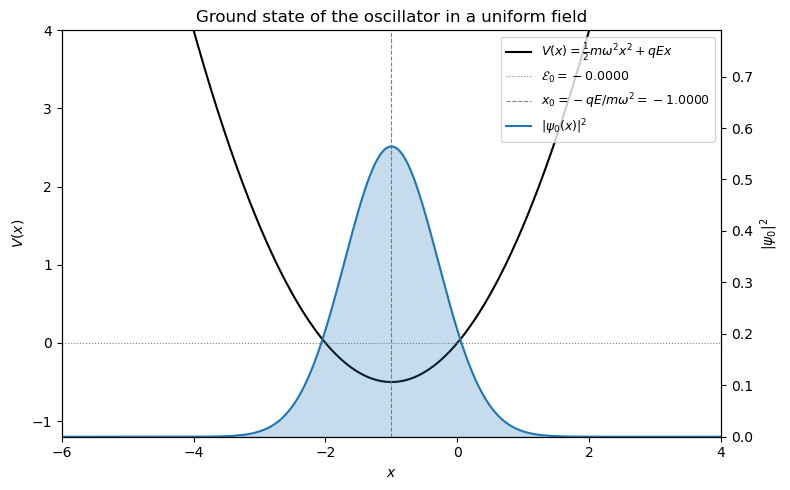

In [4]:
dx = x[1] - x[0]
rho0 = states[:, 0]**2 / dx                      # probability density, integrates to 1
x0 = -qE/(m*omega**2)                            # potential minimum
x_mean = np.sum(x*rho0)*dx
width = np.sqrt(np.sum((x - x_mean)**2*rho0)*dx)
print(f"integral of |psi_0|^2 = {np.sum(rho0)*dx:.4f}")
print(f"<x>   = {x_mean:.4f}   (potential minimum x0 = {x0:.4f})")
print(f"width = {width:.4f}   (sqrt(hbar / 2 m omega) = {np.sqrt(hbar/(2*m*omega)):.4f})")


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, 0.5*m*omega**2*x**2 + qE*x, 'k-', lw=1.5, label=r'$V(x) = \frac{1}{2}m\omega^2x^2 + qEx$')
ax.axhline(E_num[0], color='gray', lw=0.8, ls=':', label=rf'$\mathcal{{E}}_0 = {E_num[0]:.4f}$')
ax.axvline(x0, color='gray', lw=0.8, ls='--', label=rf'$x_0 = -qE/m\omega^2 = {x0:.4f}$')
ax.set_xlim(-6, 4)
ax.set_ylim(-1.2, 4)
ax.set_xlabel('$x$')
ax.set_ylabel('$V(x)$')
ax_rho = ax.twinx()
ax_rho.fill_between(x, rho0, alpha=0.25, color='C0')
ax_rho.plot(x, rho0, color='C0', lw=1.5, label=r'$|\psi_0(x)|^2$')
ax_rho.set_ylabel(r'$|\psi_0|^2$')
ax_rho.set_ylim(0, 1.4*rho0.max())
handles = ax.get_legend_handles_labels()[0] + ax_rho.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + ax_rho.get_legend_handles_labels()[1]
ax.legend(handles, labels, loc='upper right', fontsize=9)
ax.set_title('Ground state of the oscillator in a uniform field')
fig.tight_layout()
fig.savefig('Potential_&_Probability_Density')

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

**Problem 2 code summary**

The script reuses `hamiltonian()` unchanged with the field added to the potential
array, which is the point of writing it generically in Problem 1. A helper solves the
eigenproblem for a given box size, keeping the grid choice in one place. The ground-state density is normalised on the grid and its mean and
width are computed numerically rather than read off the plot, so the comparison with the
shifted-oscillator prediction is quantitative.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)